# Analisis 5W+1H - Chicago Crime (Part 5: HOW)

Bagian ini berfokus pada **HOW (Bagaimana)**, menganalisis tingkat keparahan (CrimeSeverity) dari tindak kejahatan yang terjadi di Chicago, tren keparahan dari tahun ke tahun, dan distribusinya terhadap jenis kejahatan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Pastikan direktori output ada
OUT = r'c:\Python\Data_Mining\output_5w1h'
os.makedirs(OUT, exist_ok=True)

print("Setup selesai.")

Setup selesai.


In [2]:
# Load data (Fallback ke CSV jika pickle dari proses sebelumnya belum ada)
pickle_path = f'{OUT}/_temp_df.pkl'

if os.path.exists(pickle_path):
    df = pd.read_pickle(pickle_path)
    print(f"Data berhasil dimuat dari pickle: {len(df):,} baris.")
    if 'CrimeSeverity' not in df.columns:
        severity_map = {'01A':'Kritis','01B':'Kritis',
            '02':'Tinggi','04A':'Tinggi','04B':'Tinggi','03':'Tinggi','15':'Tinggi',
            '05':'Sedang','06':'Sedang','07':'Sedang','09':'Sedang','08A':'Sedang','08B':'Sedang',
            '10':'Rendah','11':'Rendah','14':'Rendah','16':'Rendah','17':'Rendah',
            '18':'Rendah','19':'Rendah','20':'Rendah','22':'Rendah','24':'Rendah','26':'Rendah'}
        df['CrimeSeverity'] = df['FBI Code'].map(severity_map).fillna('Rendah')
        df.to_pickle(pickle_path)
else:
    print("File pickle tidak ditemukan. Memuat dari Mining.csv dan melakukan preprocessing...")
    cols = ['Date','Primary Type','Description','Location Description',
            'Arrest','Domestic','District','Ward','Community Area',
            'Year','Latitude','Longitude','Beat','IUCR','FBI Code','Block']
    df = pd.read_csv(r'c:\Python\Data_Mining\Mining.csv', usecols=cols, nrows=500000, low_memory=False)
    df = df.sample(n=300000, random_state=42).reset_index(drop=True)

    # Feature Engineering yang diperlukan untuk seluruh analisis 5W1H
    df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
    df['Hour'] = df['Date'].dt.hour
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Month'] = df['Date'].dt.month

    season_map = {12:'Winter',1:'Winter',2:'Winter',
                  3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',
                  9:'Fall',10:'Fall',11:'Fall'}
    df['Season'] = df['Month'].map(season_map)
    df['IsNight'] = df['Hour'].apply(lambda x: 1 if (x >= 22 or x < 6) else 0)
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

    day_map = {0:'Senin', 1:'Selasa', 2:'Rabu', 3:'Kamis', 4:'Jumat', 5:'Sabtu', 6:'Minggu'}
    df['DayName'] = df['DayOfWeek'].map(day_map)

    severity_map = {'01A':'Kritis','01B':'Kritis',
        '02':'Tinggi','04A':'Tinggi','04B':'Tinggi','03':'Tinggi','15':'Tinggi',
        '05':'Sedang','06':'Sedang','07':'Sedang','09':'Sedang','08A':'Sedang','08B':'Sedang',
        '10':'Rendah','11':'Rendah','14':'Rendah','16':'Rendah','17':'Rendah',
        '18':'Rendah','19':'Rendah','20':'Rendah','22':'Rendah','24':'Rendah','26':'Rendah'}
    df['CrimeSeverity'] = df['FBI Code'].map(severity_map).fillna('Rendah')

    df.to_pickle(pickle_path)
    print(f"Pre-processing selesai. Data disimpan ke pickle. Sample: {len(df):,} rows.")

Data berhasil dimuat dari pickle: 300,000 baris.


---
## OPSI 5: HOW - Bagaimana Tingkat Keparahan Kejahatannya?
---


[5.1] Proporsi Tingkat Keparahan Kejahatan (CrimeSeverity):


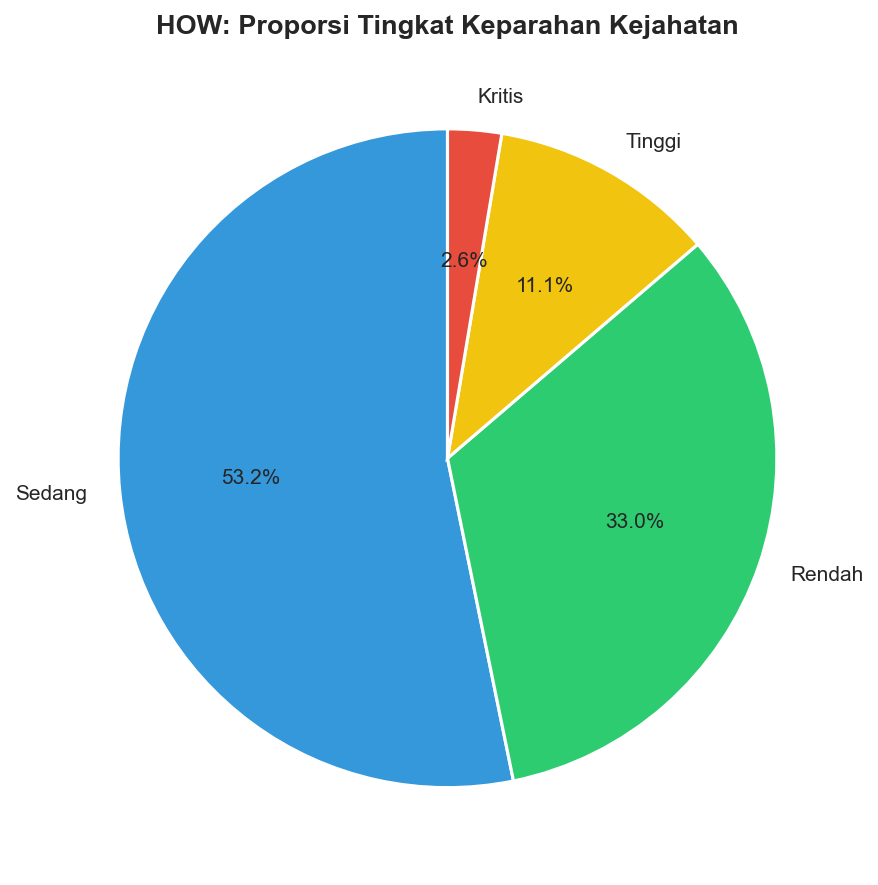

In [3]:
print("\n[5.1] Proporsi Tingkat Keparahan Kejahatan (CrimeSeverity):")
sev_counts = df['CrimeSeverity'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(sev_counts, labels=sev_counts.index, autopct='%1.1f%%', 
       colors=['#3498db', '#2ecc71', '#f1c40f', '#e74c3c'], startangle=90,
       wedgeprops=dict(edgecolor='w', linewidth=1.5))
ax.set_title('HOW: Proporsi Tingkat Keparahan Kejahatan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/how_01_severity_pie.png', bbox_inches='tight')
plt.show()


[5.2] Tren Tingkat Keparahan Kejahatan per Tahun:


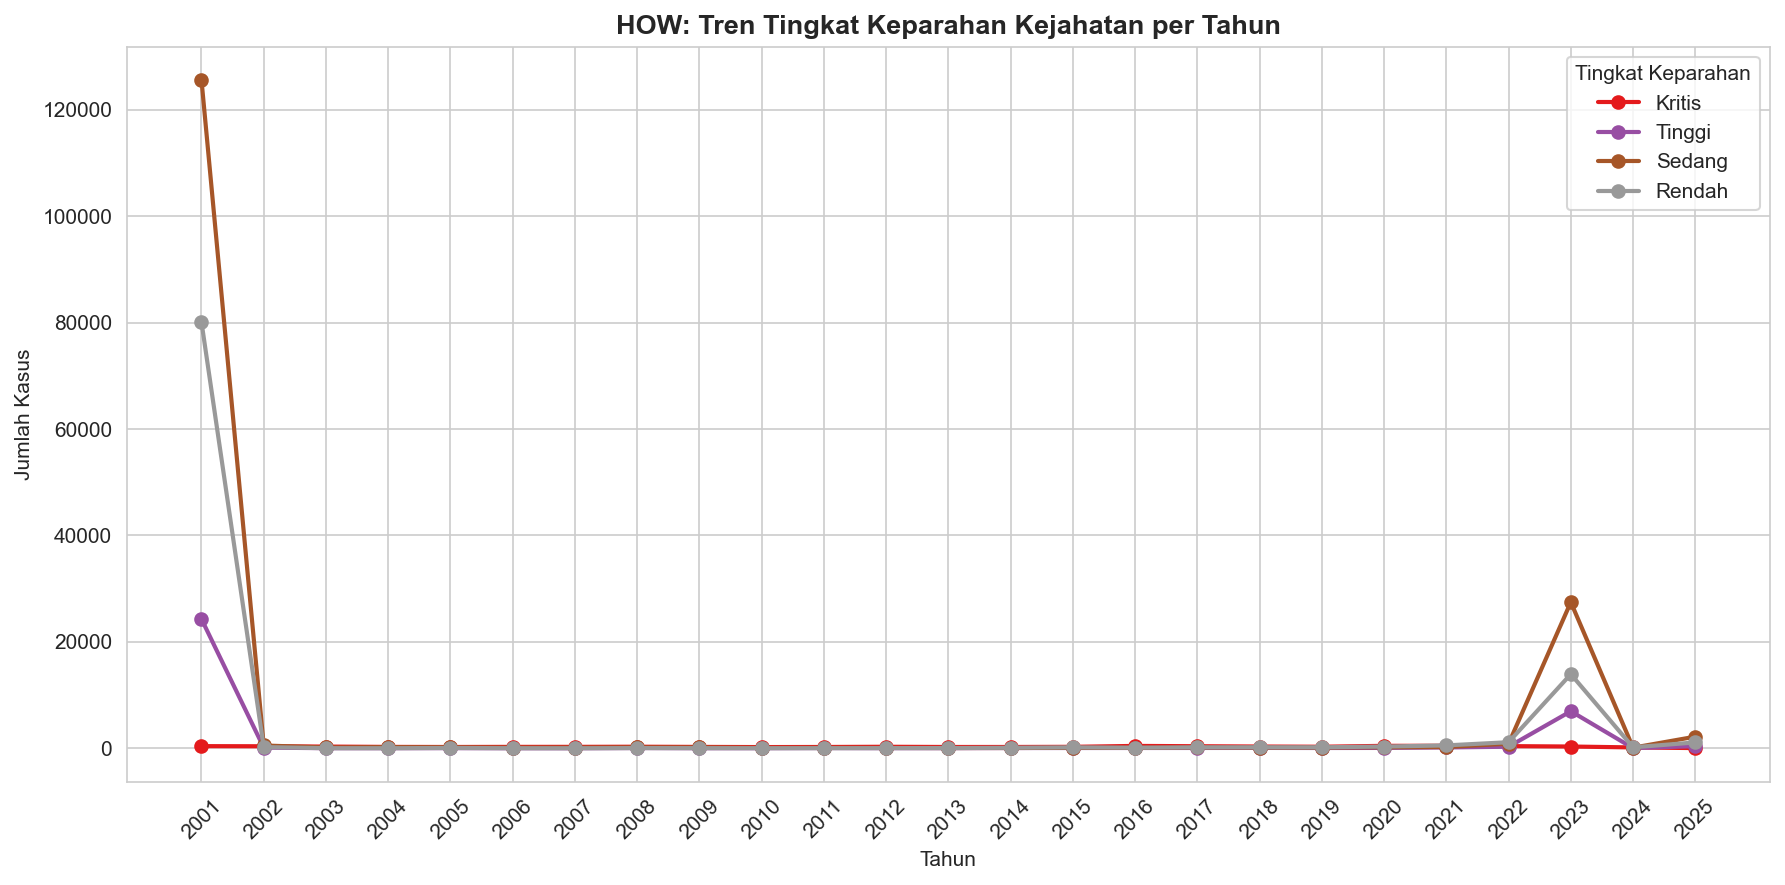

In [4]:
print("\n[5.2] Tren Tingkat Keparahan Kejahatan per Tahun:")
yearly_sev = pd.crosstab(df['Year'], df['CrimeSeverity'])
# Urutkan secara logikal jika datanya tersedia
order = [c for c in ['Kritis', 'Tinggi', 'Sedang', 'Rendah'] if c in yearly_sev.columns]
yearly_sev = yearly_sev[order]

fig, ax = plt.subplots(figsize=(12, 6))
yearly_sev.plot(kind='line', marker='o', ax=ax, linewidth=2, cmap='Set1')
ax.set_title('HOW: Tren Tingkat Keparahan Kejahatan per Tahun', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahun')
ax.set_ylabel('Jumlah Kasus')
plt.xticks(yearly_sev.index, rotation=45)
plt.legend(title='Tingkat Keparahan')
plt.tight_layout()
plt.savefig(f'{OUT}/how_02_severity_trend.png', bbox_inches='tight')
plt.show()


[5.3] Distribusi Keparahan pada Top 10 Jenis Kejahatan Utama:


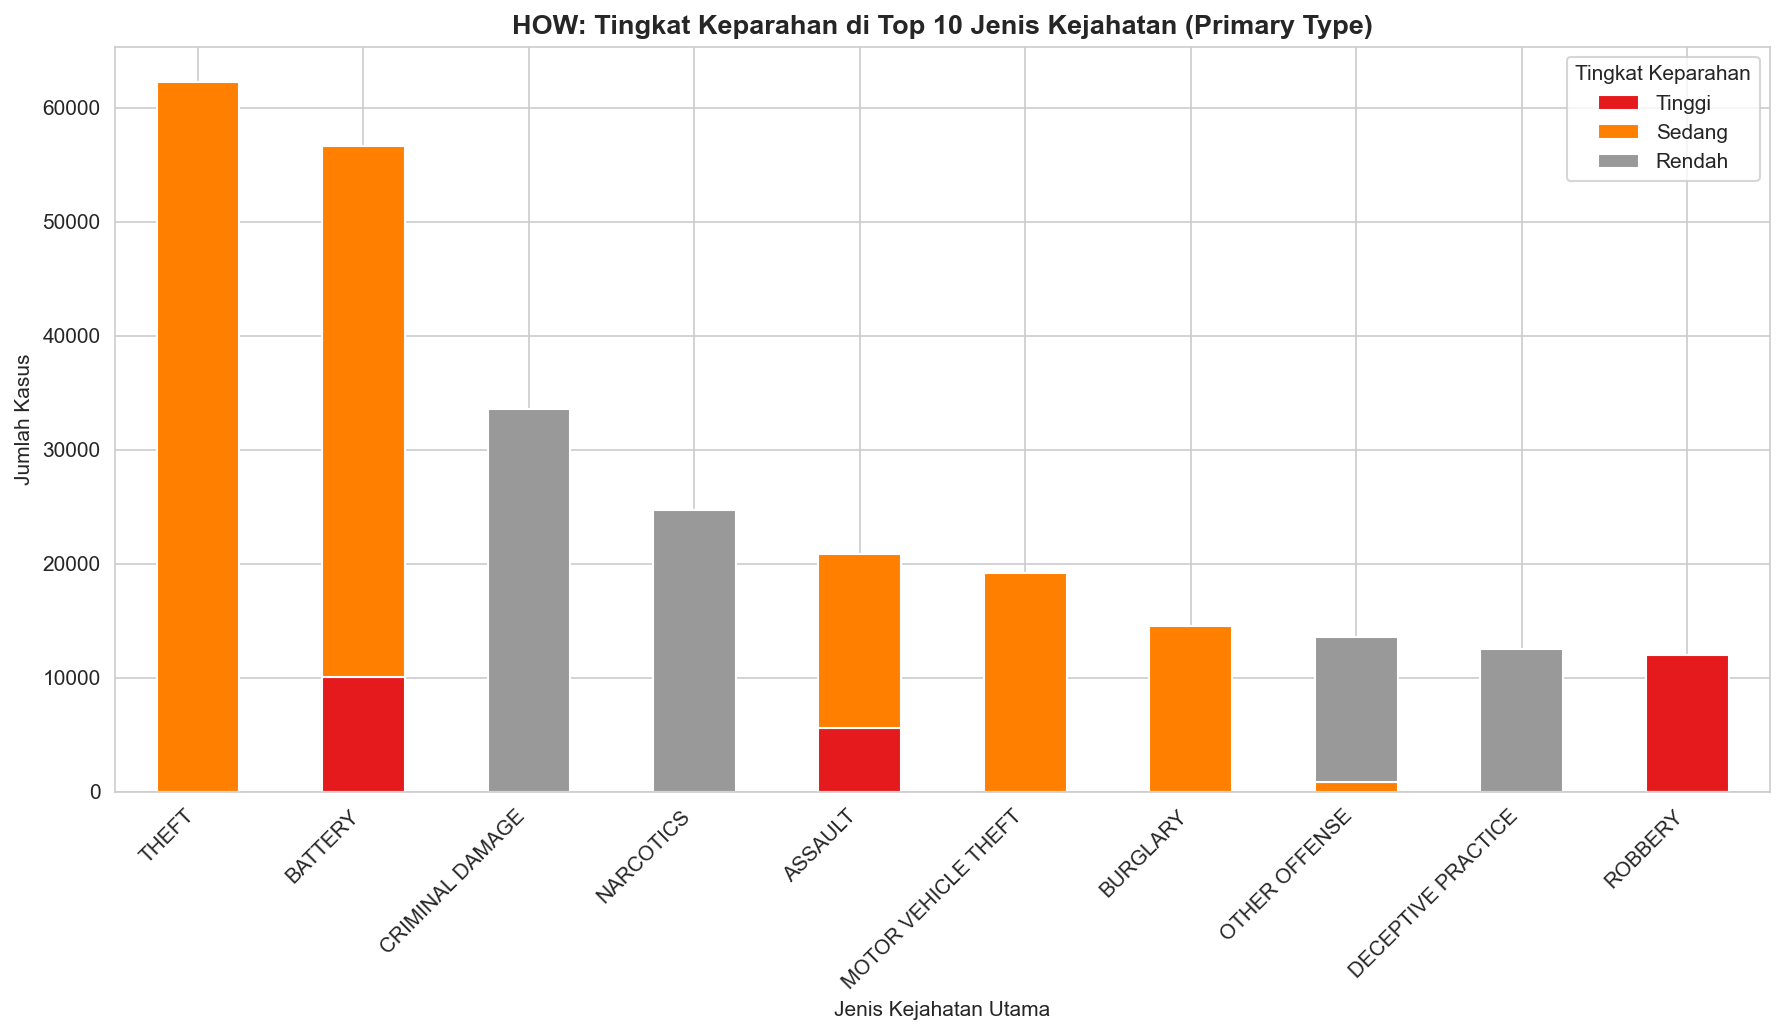

  [Saved] how_01 ~ how_03


In [5]:
print("\n[5.3] Distribusi Keparahan pada Top 10 Jenis Kejahatan Utama:")
top10_crimes = df['Primary Type'].value_counts().head(10).index
df_top10 = df[df['Primary Type'].isin(top10_crimes)]

ct_type_sev = pd.crosstab(df_top10['Primary Type'], df_top10['CrimeSeverity'])
ct_type_sev = ct_type_sev.reindex(index=top10_crimes)
ct_type_sev = ct_type_sev[[c for c in order if c in ct_type_sev.columns]] # Tetap menggunakan urutan tingkat

fig, ax = plt.subplots(figsize=(12, 7))
ct_type_sev.plot(kind='bar', stacked=True, ax=ax, cmap='Set1')
ax.set_title('HOW: Tingkat Keparahan di Top 10 Jenis Kejahatan (Primary Type)', fontsize=13, fontweight='bold')
ax.set_xlabel('Jenis Kejahatan Utama')
ax.set_ylabel('Jumlah Kasus')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tingkat Keparahan')
plt.tight_layout()
plt.savefig(f'{OUT}/how_03_severity_type.png', bbox_inches='tight')
plt.show()
print("  [Saved] how_01 ~ how_03")